In [15]:
import os
from dotenv import load_dotenv
import requests
import pandas as pd
import json
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

load_dotenv()

# Configuración de la API
API_KEY = os.getenv("API_KEY")
API_HOST = os.getenv("API_HOST")
BASE_URL = "https://meteostat.p.rapidapi.com/stations/daily"

# Parámetros de la consulta
params = {
    "station": os.getenv("STATION", "10637"),
    "start": os.getenv("START_DATE", "2015-03-01"),
    "end": os.getenv("END_DATE", "2025-01-01"),
    "tz": os.getenv("TIMEZONE", "America/El_Salvador")
}

# Headers requeridos por RapidAPI
headers = {
    "X-RapidAPI-Key": API_KEY,
    "X-RapidAPI-Host": "meteostat.p.rapidapi.com"
}

# Realizar la petición
try:
    response = requests.get(BASE_URL, headers=headers, params=params)
    response.raise_for_status()  # Lanza excepción si hay error HTTP

    # Obtener los datos
    data = response.json()

    print("✓ Datos obtenidos exitosamente")
    print(f"Status Code: {response.status_code}")

    # Convertir a DataFrame de pandas para análisis
    if 'data' in data:
        df = pd.DataFrame(data['data'])

        # Convertir la columna de fecha a datetime
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])

        print(f"\nTotal de registros: {len(df)}")
        print("\nPrimeras filas:")
        print(df.head())

    else:
        print("Respuesta completa:", json.dumps(data, indent=2))

except requests.exceptions.HTTPError as e:
    print(f"✗ Error HTTP: {e}")
    print(f"Respuesta: {response.text}")
except requests.exceptions.RequestException as e:
    print(f"✗ Error en la petición: {e}")
except json.JSONDecodeError:
    print(f"✗ Error al decodificar JSON. Respuesta: {response.text}")

✓ Datos obtenidos exitosamente
Status Code: 200

Total de registros: 3595

Primeras filas:
        date  tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt    pres  tsun
0 2015-03-01   6.4   2.3  10.3   1.5   0.0  None  20.5  55.4  1008.4    66
1 2015-03-02   6.7   1.8  10.2   0.4   0.0  None  25.2  78.8  1008.8   276
2 2015-03-03   5.5  -0.1  10.8   1.2   0.0  None  22.0  61.2  1020.9   402
3 2015-03-04   4.3   0.8   8.2   0.2   0.0  None  16.2  64.1  1027.2   318
4 2015-03-05   5.0   0.7   8.5   0.0   0.0  None  11.9  35.3  1037.3   234


In [16]:
print("\nColumnas disponibles:")
print(df.columns.tolist())

print("\nInformación del DataFrame:")
print(df.info())


Columnas disponibles:
['date', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun']

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3595 entries, 0 to 3594
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3595 non-null   datetime64[ns]
 1   tavg    3595 non-null   float64       
 2   tmin    3595 non-null   float64       
 3   tmax    3595 non-null   float64       
 4   prcp    3595 non-null   float64       
 5   snow    3595 non-null   float64       
 6   wdir    0 non-null      object        
 7   wspd    3595 non-null   float64       
 8   wpgt    3594 non-null   float64       
 9   pres    3595 non-null   float64       
 10  tsun    3595 non-null   int64         
dtypes: datetime64[ns](1), float64(8), int64(1), object(1)
memory usage: 309.1+ KB
None


In [17]:
# Limpieza y preparación de datos para ML

# Renombrar columnas al español
column_mapping = {
    'date': 'fecha',
    'tavg': 'temp_promedio',
    'tmin': 'temp_minima',
    'tmax': 'temp_maxima',
    'prcp': 'precipitacion',
    'snow': 'nieve',
    'wdir': 'direccion_viento',
    'wspd': 'velocidad_viento',
    'wpgt': 'rafaga_viento',
    'pres': 'presion_atmosferica',
    'tsun': 'horas_sol'
}

df = df.rename(columns=column_mapping)

print("Columnas renombradas:")
print(df.columns.tolist())

# Crear una copia para no modificar los datos originales
df_clean = df.copy()

# 1. Manejo de valores nulos
print("Valores nulos por columna:")
print(df_clean.isnull().sum())

# 2. Eliminar columnas con demasiados valores nulos (>50%)
threshold = len(df_clean) * 0.5
df_clean = df_clean.dropna(thresh=threshold, axis=1)

# 3. Rellenar valores nulos en columnas numéricas con la mediana
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 4. Eliminar filas con valores nulos restantes
df_clean = df_clean.dropna()

# 5. Eliminar duplicados basados en la fecha
df_clean = df_clean.drop_duplicates(subset=['fecha'], keep='first')

# 6. Ordenar por fecha
df_clean = df_clean.sort_values('fecha').reset_index(drop=True)

# 7. Verificar outliers usando IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers)

print("\nOutliers detectados por columna:")
for col in numeric_columns:
    if col in df_clean.columns:
        n_outliers = detect_outliers_iqr(df_clean, col)
        print(f"{col}: {n_outliers} outliers")

# 8. Mostrar columnas disponibles después de la limpieza
print("\nColumnas disponibles después de limpieza:")
print(df_clean.columns.tolist())

# 9. Información del DataFrame limpio
print("\nInformación del DataFrame limpio:")
print(df_clean.info())

# 10. Resumen final
print(f"\nDatos originales: {len(df)} filas")
print(f"Datos limpios: {len(df_clean)} filas")
print(f"Columnas finales: {df_clean.shape[1]}")
print("\nPrimeras filas del dataset limpio:")
print(df_clean.head())

Columnas renombradas:
['fecha', 'temp_promedio', 'temp_minima', 'temp_maxima', 'precipitacion', 'nieve', 'direccion_viento', 'velocidad_viento', 'rafaga_viento', 'presion_atmosferica', 'horas_sol']
Valores nulos por columna:
fecha                     0
temp_promedio             0
temp_minima               0
temp_maxima               0
precipitacion             0
nieve                     0
direccion_viento       3595
velocidad_viento          0
rafaga_viento             1
presion_atmosferica       0
horas_sol                 0
dtype: int64

Outliers detectados por columna:
temp_promedio: 0 outliers
temp_minima: 0 outliers
temp_maxima: 0 outliers
precipitacion: 559 outliers
nieve: 42 outliers
velocidad_viento: 121 outliers
rafaga_viento: 84 outliers
presion_atmosferica: 81 outliers
horas_sol: 0 outliers

Columnas disponibles después de limpieza:
['fecha', 'temp_promedio', 'temp_minima', 'temp_maxima', 'precipitacion', 'nieve', 'velocidad_viento', 'rafaga_viento', 'presion_atmosferica', 

Varianza explicada por cada componente:
PC1: 36.67%
PC2: 24.99%
PC3: 12.07%
PC4: 10.81%
PC5: 7.17%
PC6: 5.57%
PC7: 2.18%
PC8: 0.49%
PC9: 0.05%

Varianza acumulada:
PC1: 36.67%
PC2: 61.65%
PC3: 73.72%
PC4: 84.54%
PC5: 91.71%
PC6: 97.28%
PC7: 99.46%
PC8: 99.95%
PC9: 100.00%


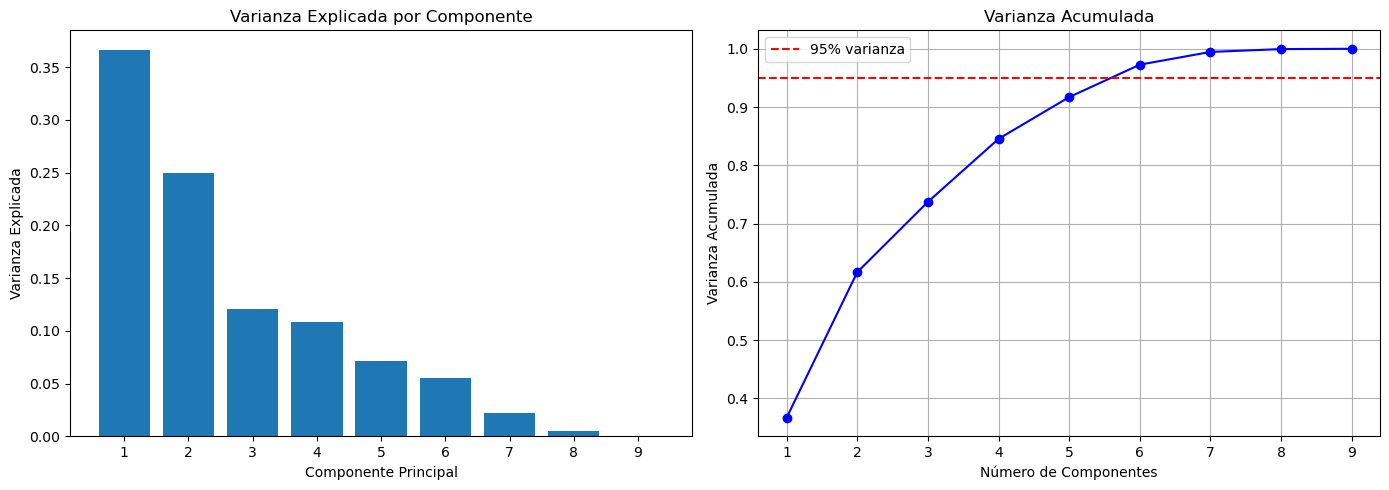


Número de componentes para explicar 95% de varianza: 6

Dimensiones originales: 9 features
Dimensiones reducidas: 6 componentes principales

Primeras filas del dataset reducido:
        PC1       PC2       PC3       PC4       PC5       PC6      fecha
0 -1.420139  2.023378 -0.570601 -0.236249 -0.660253  0.178077 2015-03-01
1 -1.133501  3.115456 -2.065763 -0.280094 -0.358521  0.747630 2015-03-02
2 -1.320362  1.408032 -1.831148 -0.372208  0.590900  0.717964 2015-03-03
3 -1.597850  0.676783 -1.762052 -0.446412  0.837042  0.252343 2015-03-04
4 -1.805146 -1.359024 -0.920279 -0.503326  1.191468 -0.540800 2015-03-05


In [18]:
# Preparar datos para PCA (excluir la columna de fecha)
df_pca = df_clean.select_dtypes(include=[np.number]).copy()

# 1. Estandarizar los datos (importante para PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_pca)

# 2. Aplicar PCA
pca = PCA()
pca_features = pca.fit_transform(df_scaled)

# 3. Analizar la varianza explicada
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print("Varianza explicada por cada componente:")
for i, var in enumerate(varianza_explicada, 1):
    print(f"PC{i}: {var*100:.2f}%")

print(f"\nVarianza acumulada:")
for i, var in enumerate(varianza_acumulada, 1):
    print(f"PC{i}: {var*100:.2f}%")

# 4. Visualizar la varianza explicada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de varianza por componente
ax1.bar(range(1, len(varianza_explicada) + 1), varianza_explicada)
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza Explicada')
ax1.set_title('Varianza Explicada por Componente')
ax1.set_xticks(range(1, len(varianza_explicada) + 1))

# Gráfico de varianza acumulada
ax2.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 'bo-')
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Acumulada')
ax2.set_title('Varianza Acumulada')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 5. Determinar número óptimo de componentes (95% varianza)
n_components_95 = np.argmax(varianza_acumulada >= 0.95) + 1
print(f"\nNúmero de componentes para explicar 95% de varianza: {n_components_95}")

# 6. Crear DataFrame con componentes principales reducidos
pca_reduced = PCA(n_components=n_components_95)
df_pca_reduced = pca_reduced.fit_transform(df_scaled)

# Crear DataFrame con los componentes principales
columnas_pca = [f'PC{i+1}' for i in range(n_components_95)]
df_final = pd.DataFrame(df_pca_reduced, columns=columnas_pca)
df_final['fecha'] = df_clean['fecha'].values

print(f"\nDimensiones originales: {df_pca.shape[1]} features")
print(f"Dimensiones reducidas: {n_components_95} componentes principales")
print(f"\nPrimeras filas del dataset reducido:")
print(df_final.head())

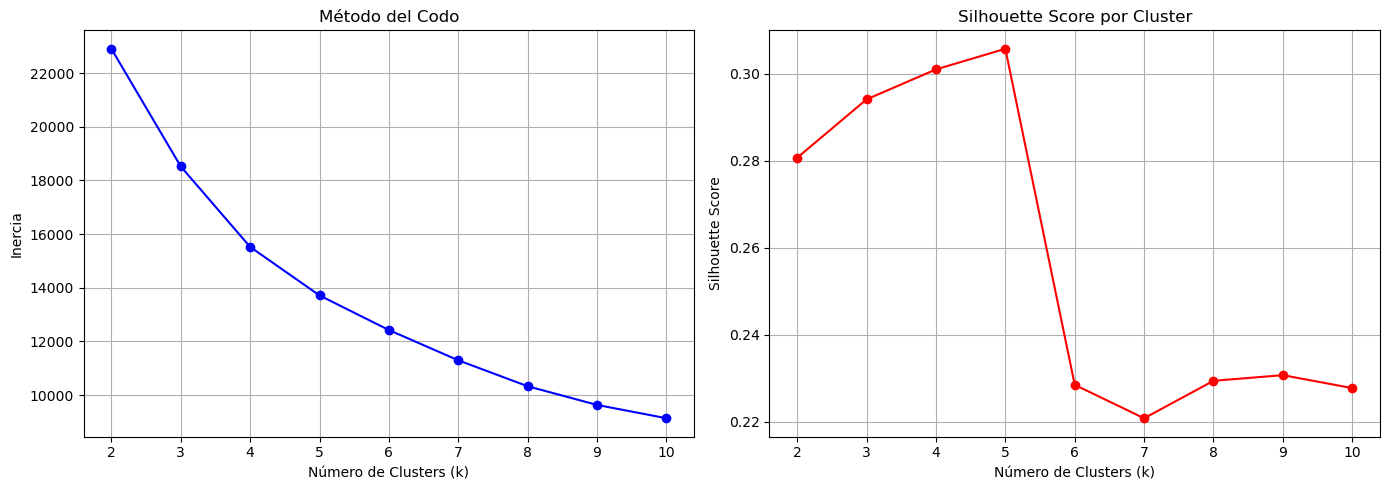

Número óptimo de clusters sugerido: 5

Métricas de calidad del clustering:
Silhouette Score: 0.306 (más cercano a 1 es mejor)
Davies-Bouldin Index: 1.087 (más cercano a 0 es mejor)
Calinski-Harabasz Score: 1162.024 (mayor es mejor)

Distribución de observaciones por cluster:
cluster
0    1389
1      25
2     704
3    1222
4     255
Name: count, dtype: int64


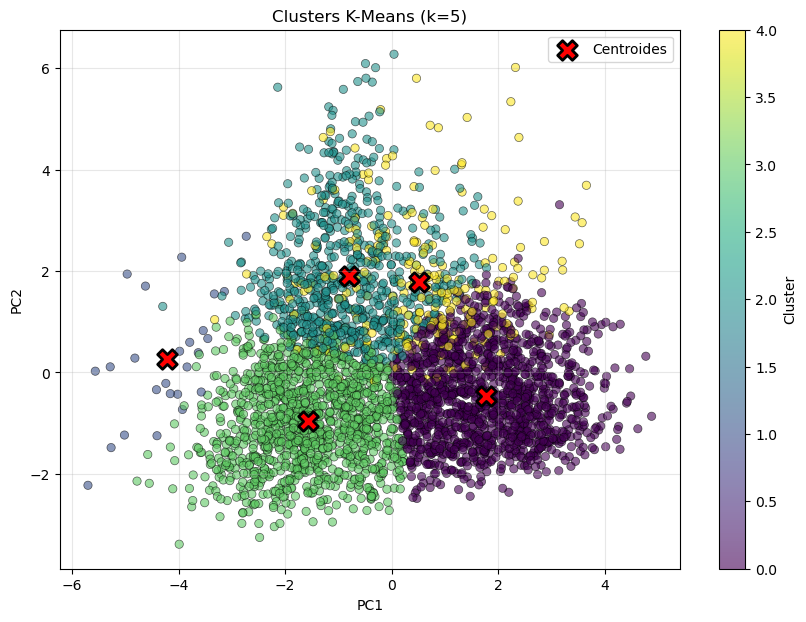


Características promedio por cluster (datos originales):

--- Cluster 0 ---
Número de días: 1389
temp_promedio            18.95
temp_minima              12.51
temp_maxima              25.27
precipitacion             0.49
nieve                     0.00
velocidad_viento         10.76
rafaga_viento            37.40
presion_atmosferica    1018.22
horas_sol               529.14
cluster                   0.00
dtype: float64

--- Cluster 1 ---
Número de días: 25
temp_promedio            -0.41
temp_minima              -3.04
temp_maxima               1.92
precipitacion             1.22
nieve                    30.40
velocidad_viento         13.39
rafaga_viento            38.28
presion_atmosferica    1015.53
horas_sol                60.48
cluster                   1.00
dtype: float64

--- Cluster 2 ---
Número de días: 704
temp_promedio             9.06
temp_minima               5.45
temp_maxima              12.40
precipitacion             2.05
nieve                     0.09
velocidad_viento    

In [19]:
# 1. Determinar el número óptimo de clusters usando el método del codo
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca_reduced)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_pca_reduced, kmeans.labels_))

# Visualizar métricas para elegir k óptimo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo')
ax1.grid(True)

# Silhouette Score
ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por Cluster')
ax2.grid(True)

plt.tight_layout()
plt.show()

# 2. Aplicar K-Means con el número óptimo de clusters
k_optimo = K_range[np.argmax(silhouette_scores)]
print(f"Número óptimo de clusters sugerido: {k_optimo}")

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(df_pca_reduced)

# 3. Agregar etiquetas de cluster al DataFrame
df_final['cluster'] = clusters

# 4. Evaluar calidad de clustering
silhouette = silhouette_score(df_pca_reduced, clusters)
davies_bouldin = davies_bouldin_score(df_pca_reduced, clusters)
calinski_harabasz = calinski_harabasz_score(df_pca_reduced, clusters)

print("\nMétricas de calidad del clustering:")
print(f"Silhouette Score: {silhouette:.3f} (más cercano a 1 es mejor)")
print(f"Davies-Bouldin Index: {davies_bouldin:.3f} (más cercano a 0 es mejor)")
print(f"Calinski-Harabasz Score: {calinski_harabasz:.3f} (mayor es mejor)")

# 5. Distribución de clusters
print("\nDistribución de observaciones por cluster:")
print(df_final['cluster'].value_counts().sort_index())

# 6. Visualizar clusters en 2D (primeros 2 componentes principales)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_final['PC1'], df_final['PC2'],
                     c=df_final['cluster'], cmap='viridis',
                     alpha=0.6, edgecolors='black', linewidth=0.5)
plt.scatter(kmeans_final.cluster_centers_[:, 0],
           kmeans_final.cluster_centers_[:, 1],
           c='red', marker='X', s=200, edgecolors='black',
           linewidth=2, label='Centroides')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Clusters K-Means (k={k_optimo})')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Características de cada cluster
print("\nCaracterísticas promedio por cluster (datos originales):")
df_clusters = df_clean.copy()
df_clusters['cluster'] = clusters

for cluster_id in range(k_optimo):
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    print(f"Número de días: {len(cluster_data)}")
    print(cluster_data.select_dtypes(include=[np.number]).mean().round(2))

print("\nPrimeras filas con clusters asignados:")
print(df_final.head(10))

Transacciones creadas:
Total de transacciones: 3595
Items únicos: 18

Items disponibles:
['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'invierno', 'lluvia_fuerte', 'lluvia_ligera', 'sin_lluvia', 'temp_alta', 'temp_baja', 'temp_media', 'transicion_lluviosa', 'transicion_seca', 'verano', 'viento_calmo', 'viento_fuerte', 'viento_moderado']

Itemsets frecuentes encontrados: 82

Top 10 itemsets más frecuentes:
     support                 itemsets
7   0.629764              (temp_baja)
6   0.561335             (sin_lluvia)
14  0.486231        (viento_moderado)
12  0.407789           (viento_calmo)
0   0.386370              (cluster_0)
8   0.340195             (temp_media)
2   0.339917              (cluster_3)
25  0.339917   (cluster_3, temp_baja)
36  0.325730  (sin_lluvia, temp_baja)
5   0.325174          (lluvia_ligera)

Reglas de asociación generadas: 248

Reglas significativas (lift>1.2, conf>0.6, sup>0.05): 71

Top 20 reglas con mayor lift:
                           

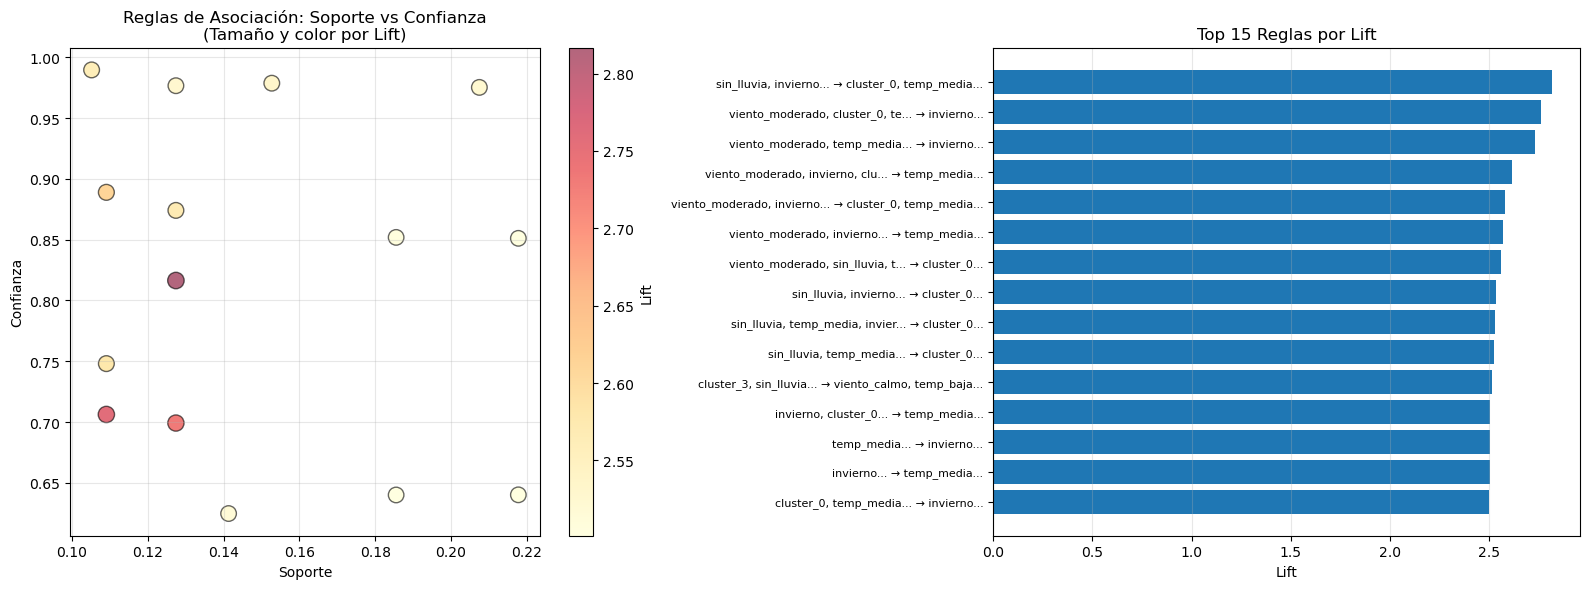


=== RESUMEN DE INSIGHTS ===
Total de reglas significativas: 71

Lift promedio: 1.98
Confianza promedio: 0.79
Soporte promedio: 0.16

Interpretación de métricas:
- Soporte: % de transacciones que contienen el itemset
- Confianza: Probabilidad de que ocurra el consecuente dado el antecedente
- Lift > 1: Indica asociación positiva (items relacionados)
- Lift = 1: Independencia (no hay relación)
- Lift < 1: Asociación negativa (items mutuamente exclusivos)


In [20]:
# 1. Preparar datos para reglas de asociación (discretizar variables continuas)
df_asociacion = df_clean.copy()
df_asociacion['cluster'] = clusters

# Discretizar variables numéricas en categorías
def discretizar_temp(x):
    if x < 15: return 'temp_baja'
    elif x < 25: return 'temp_media'
    else: return 'temp_alta'

def discretizar_precipitacion(x):
    if x == 0: return 'sin_lluvia'
    elif x < 5: return 'lluvia_ligera'
    else: return 'lluvia_fuerte'

def discretizar_viento(x):
    if pd.isna(x): return 'viento_na'
    elif x < 10: return 'viento_calmo'
    elif x < 20: return 'viento_moderado'
    else: return 'viento_fuerte'

# Aplicar discretización
df_asociacion['cat_temp'] = df_asociacion['temp_promedio'].apply(discretizar_temp)
df_asociacion['cat_precipitacion'] = df_asociacion['precipitacion'].apply(discretizar_precipitacion)
df_asociacion['cat_viento'] = df_asociacion['velocidad_viento'].apply(discretizar_viento)
df_asociacion['cat_cluster'] = df_asociacion['cluster'].apply(lambda x: f'cluster_{x}')

# Agregar estación del año
df_asociacion['mes'] = pd.to_datetime(df_asociacion['fecha']).dt.month
def obtener_estacion(mes):
    if mes in [12, 1, 2]: return 'verano'  # El Salvador
    elif mes in [3, 4, 5]: return 'transicion_seca'
    elif mes in [6, 7, 8]: return 'invierno'
    else: return 'transicion_lluviosa'

df_asociacion['estacion'] = df_asociacion['mes'].apply(obtener_estacion)

# 2. Crear transacciones (cada fila es una transacción con items)
transacciones = []
for _, row in df_asociacion.iterrows():
    transaccion = [
        row['cat_temp'],
        row['cat_precipitacion'],
        row['cat_viento'],
        row['cat_cluster'],
        row['estacion']
    ]
    transacciones.append(transaccion)

# 3. Codificar transacciones
te = TransactionEncoder()
te_array = te.fit(transacciones).transform(transacciones)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print("Transacciones creadas:")
print(f"Total de transacciones: {len(transacciones)}")
print(f"Items únicos: {len(te.columns_)}")
print("\nItems disponibles:")
print(list(te.columns_))

# 4. Encontrar itemsets frecuentes con Apriori
frequent_itemsets = apriori(df_encoded, min_support=0.1, use_colnames=True)
print(f"\nItemsets frecuentes encontrados: {len(frequent_itemsets)}")
print("\nTop 10 itemsets más frecuentes:")
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

# 5. Generar reglas de asociación
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)

print(f"\nReglas de asociación generadas: {len(rules)}")

# 6. Filtrar y mostrar las mejores reglas
reglas_significativas = rules[
    (rules['lift'] > 1.2) &
    (rules['confidence'] > 0.6) &
    (rules['support'] > 0.05)
].copy()

print(f"\nReglas significativas (lift>1.2, conf>0.6, sup>0.05): {len(reglas_significativas)}")

# Formatear para mejor visualización
reglas_significativas['antecedents'] = reglas_significativas['antecedents'].apply(lambda x: ', '.join(list(x)))
reglas_significativas['consequents'] = reglas_significativas['consequents'].apply(lambda x: ', '.join(list(x)))

# Seleccionar columnas relevantes
columnas_mostrar = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print("\nTop 20 reglas con mayor lift:")
print(reglas_significativas[columnas_mostrar].head(20).to_string(index=False))

# 7. Análisis de reglas por cluster
print("\n=== Reglas específicas por cluster ===")
for cluster_id in range(k_optimo):
    cluster_name = f'cluster_{cluster_id}'
    reglas_cluster = reglas_significativas[
        reglas_significativas['consequents'].str.contains(cluster_name)
    ]
    if len(reglas_cluster) > 0:
        print(f"\n--- Reglas que predicen {cluster_name} ---")
        print(reglas_cluster[columnas_mostrar].head(5).to_string(index=False))

# 8. Visualizar las mejores reglas
top_rules = reglas_significativas.head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Soporte vs Confianza coloreado por Lift
scatter = ax1.scatter(top_rules['support'], top_rules['confidence'],
                     s=top_rules['lift']*50, c=top_rules['lift'],
                     cmap='YlOrRd', alpha=0.6, edgecolors='black')
ax1.set_xlabel('Soporte')
ax1.set_ylabel('Confianza')
ax1.set_title('Reglas de Asociación: Soporte vs Confianza\n(Tamaño y color por Lift)')
plt.colorbar(scatter, ax=ax1, label='Lift')
ax1.grid(True, alpha=0.3)

# Gráfico de barras con las mejores reglas por Lift
reglas_labels = [f"{ant[:30]}... → {cons[:30]}..."
                for ant, cons in zip(top_rules['antecedents'], top_rules['consequents'])]
ax2.barh(range(len(top_rules)), top_rules['lift'].values)
ax2.set_yticks(range(len(top_rules)))
ax2.set_yticklabels(reglas_labels, fontsize=8)
ax2.set_xlabel('Lift')
ax2.set_title('Top 15 Reglas por Lift')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 9. Resumen de insights
print("\n=== RESUMEN DE INSIGHTS ===")
print(f"Total de reglas significativas: {len(reglas_significativas)}")
print(f"\nLift promedio: {reglas_significativas['lift'].mean():.2f}")
print(f"Confianza promedio: {reglas_significativas['confidence'].mean():.2f}")
print(f"Soporte promedio: {reglas_significativas['support'].mean():.2f}")

print("\nInterpretación de métricas:")
print("- Soporte: % de transacciones que contienen el itemset")
print("- Confianza: Probabilidad de que ocurra el consecuente dado el antecedente")
print("- Lift > 1: Indica asociación positiva (items relacionados)")
print("- Lift = 1: Independencia (no hay relación)")
print("- Lift < 1: Asociación negativa (items mutuamente exclusivos)")

Aplicando UMAP...


C:\Users\arani\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Dimensiones originales: 9 features
Dimensiones reducidas (UMAP): 2 componentes

Primeras filas del dataset reducido con UMAP:
      UMAP1      UMAP2      fecha
0  2.111993   7.087639 2015-03-01
1  3.514367   7.360546 2015-03-02
2  2.030941   8.580831 2015-03-03
3  1.756828   8.779034 2015-03-04
4 -2.523566  10.488074 2015-03-05


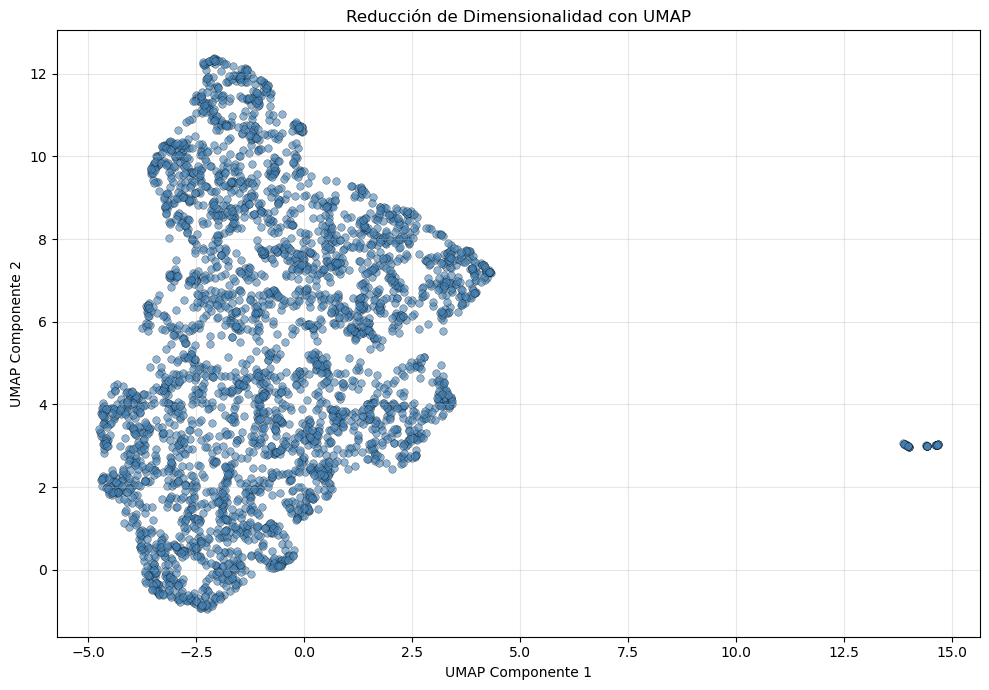


✓ Reducción con UMAP completada
Dataset alternativo guardado en: df_umap_final
Array reducido guardado en: df_umap_reduced


In [21]:
# Preparar datos para UMAP (excluir la columna de fecha)
df_umap_input = df_clean.select_dtypes(include=[np.number]).copy()

# 1. Estandarizar los datos (importante para UMAP)
scaler_umap = StandardScaler()
df_scaled_umap = scaler_umap.fit_transform(df_umap_input)

# 2. Aplicar UMAP para reducción a 2D
print("Aplicando UMAP...")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
df_umap_reduced = reducer.fit_transform(df_scaled_umap)

# 3. Crear DataFrame con componentes reducidos
df_umap_final = pd.DataFrame(df_umap_reduced, columns=['UMAP1', 'UMAP2'])
df_umap_final['fecha'] = df_clean['fecha'].values

print(f"\nDimensiones originales: {df_umap_input.shape[1]} features")
print(f"Dimensiones reducidas (UMAP): 2 componentes")
print("\nPrimeras filas del dataset reducido con UMAP:")
print(df_umap_final.head())

# 4. Visualizar la reducción UMAP
plt.figure(figsize=(10, 7))
plt.scatter(df_umap_final['UMAP1'], df_umap_final['UMAP2'],
            alpha=0.6, edgecolors='black', linewidth=0.3, s=30, c='steelblue')
plt.xlabel('UMAP Componente 1')
plt.ylabel('UMAP Componente 2')
plt.title('Reducción de Dimensionalidad con UMAP')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Reducción con UMAP completada")
print(f"Dataset alternativo guardado en: df_umap_final")
print(f"Array reducido guardado en: df_umap_reduced")

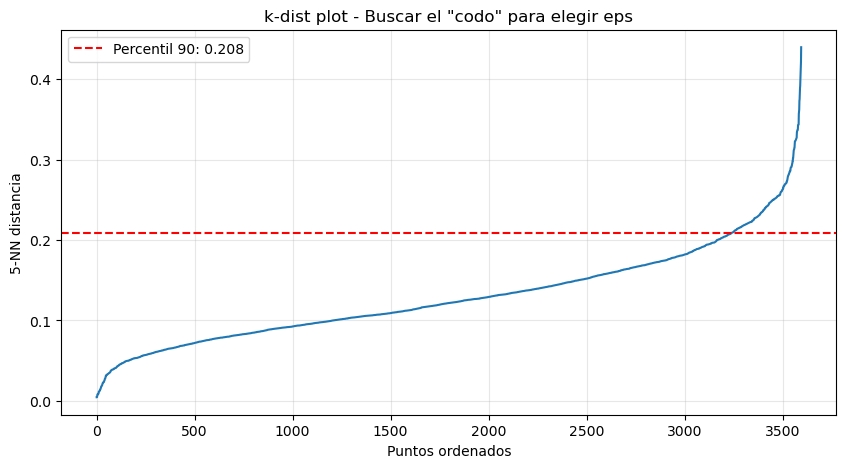

eps sugerido (percentil 90): 0.2083

Clusters encontrados: 30
Puntos de ruido (-1): 121 (3.4%)

Distribución por cluster:
-1      121
 0     1045
 1      162
 2      226
 3       53
 4     1563
 5        6
 6       66
 7       21
 8       16
 9       52
 10      16
 11      10
 12      15
 13      17
 14      21
 15      22
 16      15
 17      25
 18      22
 19      18
 20       5
 21      21
 22      12
 23      12
 24       8
 25       5
 26       5
 27       5
 28       5
 29       5
Name: count, dtype: int64

Métricas de calidad (sin ruido):
Silhouette Score: -0.311
Davies-Bouldin Index: 1.358
Calinski-Harabasz Score: 355.606


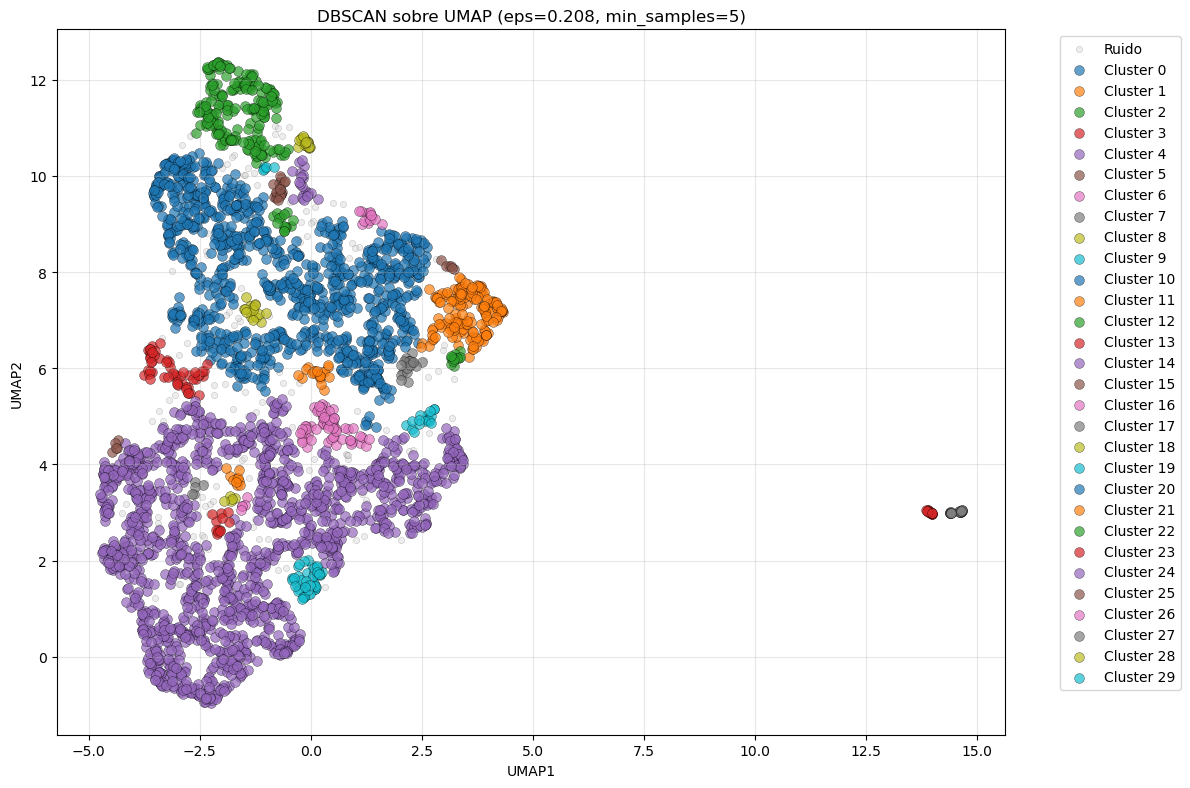


=== Características promedio por cluster ===

--- Ruido (cluster -1) ---
Número de días: 121
temp_promedio            11.16
temp_minima               6.17
temp_maxima              15.96
precipitacion             1.45
nieve                     0.00
velocidad_viento         12.38
rafaga_viento            40.48
presion_atmosferica    1019.10
horas_sol               257.16
dbscan_cluster           -1.00
dtype: float64

--- Cluster 0 ---
Número de días: 1045
temp_promedio             5.83
temp_minima               2.40
temp_maxima               8.87
precipitacion             1.49
nieve                     0.00
velocidad_viento         12.09
rafaga_viento            36.22
presion_atmosferica    1017.55
horas_sol                84.68
dbscan_cluster            0.00
dtype: float64

--- Cluster 1 ---
Número de días: 162
temp_promedio             9.48
temp_minima               6.31
temp_maxima              12.38
precipitacion             2.75
nieve                     0.00
velocidad_viento      

In [22]:
# Usar el dataset reducido con UMAP (solo las 2 componentes)
X_umap = df_umap_reduced  # array numpy con UMAP1 y UMAP2

# 1. Calcular eps óptimo con k-dist plot
min_samples = 5  # puedes ajustar este valor
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_umap)
distances, _ = nbrs.kneighbors(X_umap)
k_distances = np.sort(distances[:, -1])

# Visualizar k-dist para elegir eps
plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.ylabel(f'{min_samples}-NN distancia')
plt.xlabel('Puntos ordenados')
plt.title('k-dist plot - Buscar el "codo" para elegir eps')
plt.grid(True, alpha=0.3)
plt.axhline(y=np.percentile(k_distances, 90), color='r', linestyle='--',
            label=f'Percentil 90: {np.percentile(k_distances, 90):.3f}')
plt.legend()
plt.show()

# 2. Elegir eps (heurístico: percentil 90)
eps_optimo = float(np.percentile(k_distances, 90))
print(f"eps sugerido (percentil 90): {eps_optimo:.4f}")

# 3. Aplicar DBSCAN
dbscan = DBSCAN(eps=eps_optimo, min_samples=min_samples, metric='euclidean')
labels_dbscan = dbscan.fit_predict(X_umap)

# 4. Agregar clusters al DataFrame UMAP
df_umap_final['dbscan_cluster'] = labels_dbscan

# 5. Resumen de clusters
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = int((labels_dbscan == -1).sum())

print(f"\nClusters encontrados: {n_clusters}")
print(f"Puntos de ruido (-1): {n_noise} ({n_noise/len(labels_dbscan)*100:.1f}%)")
print("\nDistribución por cluster:")
print(pd.Series(labels_dbscan).value_counts().sort_index())

# 6. Métricas de calidad (excluyendo ruido)
valid_mask = labels_dbscan != -1
if n_clusters >= 2 and valid_mask.sum() > 0:
    silhouette = silhouette_score(X_umap[valid_mask], labels_dbscan[valid_mask])
    davies_bouldin = davies_bouldin_score(X_umap[valid_mask], labels_dbscan[valid_mask])
    calinski = calinski_harabasz_score(X_umap[valid_mask], labels_dbscan[valid_mask])

    print("\nMétricas de calidad (sin ruido):")
    print(f"Silhouette Score: {silhouette:.3f}")
    print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")
    print(f"Calinski-Harabasz Score: {calinski:.3f}")
else:
    print("\nNo se pueden calcular métricas (menos de 2 clusters válidos)")

# 7. Visualizar clusters DBSCAN sobre UMAP
plt.figure(figsize=(12, 8))

# Graficar ruido primero
noise_mask = labels_dbscan == -1
if noise_mask.sum() > 0:
    plt.scatter(df_umap_final.loc[noise_mask, 'UMAP1'],
                df_umap_final.loc[noise_mask, 'UMAP2'],
                c='lightgray', s=20, alpha=0.4, label='Ruido',
                edgecolors='black', linewidth=0.2)

# Graficar clusters
for cluster_id in sorted(set(labels_dbscan)):
    if cluster_id == -1:
        continue
    cluster_mask = labels_dbscan == cluster_id
    plt.scatter(df_umap_final.loc[cluster_mask, 'UMAP1'],
                df_umap_final.loc[cluster_mask, 'UMAP2'],
                s=50, alpha=0.7, label=f'Cluster {cluster_id}',
                edgecolors='black', linewidth=0.3)

plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title(f'DBSCAN sobre UMAP (eps={eps_optimo:.3f}, min_samples={min_samples})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Características promedio por cluster (datos originales)
print("\n=== Características promedio por cluster ===")
df_dbscan_clusters = df_clean.copy()
df_dbscan_clusters['dbscan_cluster'] = labels_dbscan

for cluster_id in sorted(set(labels_dbscan)):
    if cluster_id == -1:
        print(f"\n--- Ruido (cluster -1) ---")
    else:
        print(f"\n--- Cluster {cluster_id} ---")

    cluster_data = df_dbscan_clusters[df_dbscan_clusters['dbscan_cluster'] == cluster_id]
    print(f"Número de días: {len(cluster_data)}")
    print(cluster_data.select_dtypes(include=[np.number]).mean().round(2))

print("\n✓ Clustering DBSCAN sobre UMAP completado")
print(f"Dataset con clusters guardado en: df_umap_final")

Transacciones creadas (UMAP + DBSCAN):
Total de transacciones: 3595
Items únicos: 44

Items disponibles:
['cluster_0', 'cluster_1', 'cluster_10', 'cluster_11', 'cluster_12', 'cluster_13', 'cluster_14', 'cluster_15', 'cluster_16', 'cluster_17', 'cluster_18', 'cluster_19', 'cluster_2', 'cluster_20', 'cluster_21', 'cluster_22', 'cluster_23', 'cluster_24', 'cluster_25', 'cluster_26', 'cluster_27', 'cluster_28', 'cluster_29', 'cluster_3', 'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7', 'cluster_8', 'cluster_9', 'invierno', 'lluvia_fuerte', 'lluvia_ligera', 'ruido', 'sin_lluvia', 'temp_alta', 'temp_baja', 'temp_media', 'transicion_lluviosa', 'transicion_seca', 'verano', 'viento_calmo', 'viento_fuerte', 'viento_moderado']

Itemsets frecuentes encontrados: 159

Reglas de asociación generadas (confidence > 0.5): 245

Reglas significativas (conf>0.6, lift>1.1, sup>0.03): 138

Top 25 reglas con mayor confidence:
                                   antecedents consequents  support  confidence  

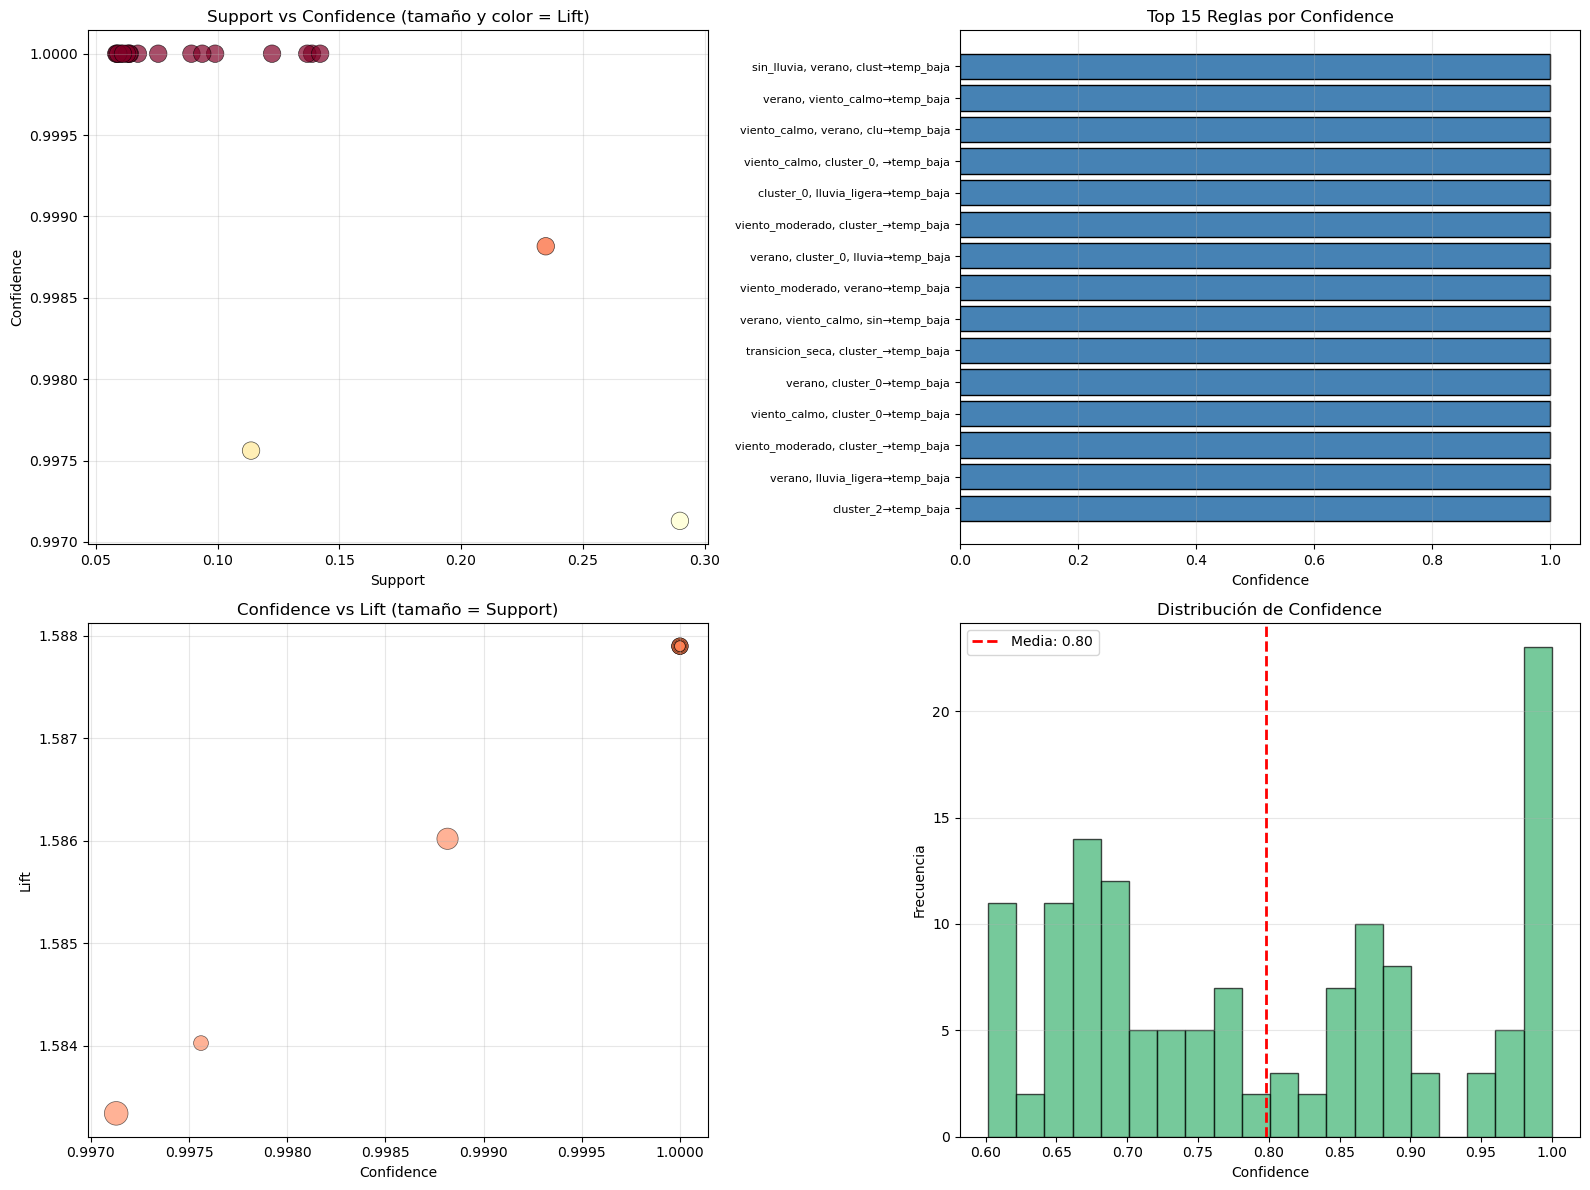


=== RESUMEN DE MÉTRICAS (UMAP + DBSCAN) ===
Total de reglas significativas: 138

Estadísticas de Confidence:
  Media: 0.798
  Mediana: 0.774
  Máximo: 1.000
  Mínimo: 0.602

Estadísticas de Lift:
  Media: 1.914
  Mediana: 2.017

Estadísticas de Support:
  Media: 0.103
  Mediana: 0.079

Interpretación:
• Confidence: P(consecuente|antecedente) - Probabilidad condicional
• Lift > 1: Asociación positiva entre antecedente y consecuente
• Support: Frecuencia de la regla en el dataset
• Leverage: Diferencia entre frecuencia observada y esperada
• Conviction: Dependencia del consecuente respecto al antecedente

✓ Reglas de asociación con confidence completadas (UMAP + DBSCAN)


In [23]:
# 1. Preparar datos para reglas de asociación usando df_umap_final con DBSCAN
df_asociacion_umap = df_clean.copy()
df_asociacion_umap['dbscan_cluster'] = labels_dbscan

# Discretizar variables numéricas en categorías
def discretizar_temp(x):
    if x < 15: return 'temp_baja'
    elif x < 25: return 'temp_media'
    else: return 'temp_alta'

def discretizar_precipitacion(x):
    if x == 0: return 'sin_lluvia'
    elif x < 5: return 'lluvia_ligera'
    else: return 'lluvia_fuerte'

def discretizar_viento(x):
    if pd.isna(x): return 'viento_na'
    elif x < 10: return 'viento_calmo'
    elif x < 20: return 'viento_moderado'
    else: return 'viento_fuerte'

# Aplicar discretización
df_asociacion_umap['cat_temp'] = df_asociacion_umap['temp_promedio'].apply(discretizar_temp)
df_asociacion_umap['cat_precipitacion'] = df_asociacion_umap['precipitacion'].apply(discretizar_precipitacion)
df_asociacion_umap['cat_viento'] = df_asociacion_umap['velocidad_viento'].apply(discretizar_viento)

# Categorizar cluster DBSCAN (incluyendo ruido)
df_asociacion_umap['cat_cluster'] = df_asociacion_umap['dbscan_cluster'].apply(
    lambda x: 'ruido' if x == -1 else f'cluster_{x}'
)

# Agregar estación del año
df_asociacion_umap['mes'] = pd.to_datetime(df_asociacion_umap['fecha']).dt.month
def obtener_estacion(mes):
    if mes in [12, 1, 2]: return 'verano'
    elif mes in [3, 4, 5]: return 'transicion_seca'
    elif mes in [6, 7, 8]: return 'invierno'
    else: return 'transicion_lluviosa'

df_asociacion_umap['estacion'] = df_asociacion_umap['mes'].apply(obtener_estacion)

# 2. Crear transacciones
transacciones_umap = []
for _, row in df_asociacion_umap.iterrows():
    transaccion = [
        row['cat_temp'],
        row['cat_precipitacion'],
        row['cat_viento'],
        row['cat_cluster'],
        row['estacion']
    ]
    transacciones_umap.append(transaccion)

# 3. Codificar transacciones
te_umap = TransactionEncoder()
te_array_umap = te_umap.fit(transacciones_umap).transform(transacciones_umap)
df_encoded_umap = pd.DataFrame(te_array_umap, columns=te_umap.columns_)

print("Transacciones creadas (UMAP + DBSCAN):")
print(f"Total de transacciones: {len(transacciones_umap)}")
print(f"Items únicos: {len(te_umap.columns_)}")
print("\nItems disponibles:")
print(list(te_umap.columns_))

# 4. Encontrar itemsets frecuentes con Apriori
frequent_itemsets_umap = apriori(df_encoded_umap, min_support=0.05, use_colnames=True)
print(f"\nItemsets frecuentes encontrados: {len(frequent_itemsets_umap)}")

# 5. Generar reglas de asociación con confidence
rules_umap = association_rules(
    frequent_itemsets_umap,
    metric="confidence",
    min_threshold=0.5
)

print(f"\nReglas de asociación generadas (confidence > 0.5): {len(rules_umap)}")

# 6. Ordenar por confidence y mostrar métricas
rules_umap = rules_umap.sort_values('confidence', ascending=False)

# Filtrar reglas significativas
reglas_significativas_umap = rules_umap[
    (rules_umap['confidence'] > 0.6) &
    (rules_umap['lift'] > 1.1) &
    (rules_umap['support'] > 0.03)
].copy()

print(f"\nReglas significativas (conf>0.6, lift>1.1, sup>0.03): {len(reglas_significativas_umap)}")

# Formatear para visualización
reglas_significativas_umap['antecedents'] = reglas_significativas_umap['antecedents'].apply(
    lambda x: ', '.join(list(x))
)
reglas_significativas_umap['consequents'] = reglas_significativas_umap['consequents'].apply(
    lambda x: ', '.join(list(x))
)

# 7. Mostrar top reglas por confidence
columnas_mostrar = ['antecedents', 'consequents', 'support', 'confidence', 'lift', 'leverage', 'conviction']
print("\nTop 25 reglas con mayor confidence:")
print(reglas_significativas_umap[columnas_mostrar].head(25).to_string(index=False))

# 8. Análisis por cluster DBSCAN
print("\n=== Reglas específicas por cluster DBSCAN ===")
clusters_dbscan = sorted(set(labels_dbscan))

for cluster_id in clusters_dbscan:
    if cluster_id == -1:
        cluster_name = 'ruido'
    else:
        cluster_name = f'cluster_{cluster_id}'

    reglas_cluster = reglas_significativas_umap[
        reglas_significativas_umap['consequents'].str.contains(cluster_name)
    ]

    if len(reglas_cluster) > 0:
        print(f"\n--- Reglas que predicen {cluster_name} ---")
        print(f"Total de reglas: {len(reglas_cluster)}")
        print(reglas_cluster[columnas_mostrar].head(5).to_string(index=False))

# 9. Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

top_20 = reglas_significativas_umap.head(20)

# Gráfico 1: Support vs Confidence (tamaño = lift)
axes[0, 0].scatter(top_20['support'], top_20['confidence'],
                   s=top_20['lift']*100, c=top_20['lift'],
                   cmap='YlOrRd', alpha=0.7, edgecolors='black', linewidth=0.5)
axes[0, 0].set_xlabel('Support')
axes[0, 0].set_ylabel('Confidence')
axes[0, 0].set_title('Support vs Confidence (tamaño y color = Lift)')
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Top 15 reglas por Confidence
top_15 = reglas_significativas_umap.head(15)
reglas_labels = [f"{ant[:25]}→{cons[:25]}"
                for ant, cons in zip(top_15['antecedents'], top_15['consequents'])]
axes[0, 1].barh(range(len(top_15)), top_15['confidence'].values, color='steelblue', edgecolor='black')
axes[0, 1].set_yticks(range(len(top_15)))
axes[0, 1].set_yticklabels(reglas_labels, fontsize=8)
axes[0, 1].set_xlabel('Confidence')
axes[0, 1].set_title('Top 15 Reglas por Confidence')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Gráfico 3: Lift vs Confidence
axes[1, 0].scatter(top_20['confidence'], top_20['lift'],
                   s=top_20['support']*1000, c='coral',
                   alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 0].set_xlabel('Confidence')
axes[1, 0].set_ylabel('Lift')
axes[1, 0].set_title('Confidence vs Lift (tamaño = Support)')
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Distribución de Confidence
axes[1, 1].hist(reglas_significativas_umap['confidence'], bins=20,
                edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[1, 1].set_xlabel('Confidence')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de Confidence')
axes[1, 1].axvline(reglas_significativas_umap['confidence'].mean(),
                   color='red', linestyle='--', linewidth=2,
                   label=f'Media: {reglas_significativas_umap["confidence"].mean():.2f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 10. Resumen estadístico
print("\n=== RESUMEN DE MÉTRICAS (UMAP + DBSCAN) ===")
print(f"Total de reglas significativas: {len(reglas_significativas_umap)}")
print(f"\nEstadísticas de Confidence:")
print(f"  Media: {reglas_significativas_umap['confidence'].mean():.3f}")
print(f"  Mediana: {reglas_significativas_umap['confidence'].median():.3f}")
print(f"  Máximo: {reglas_significativas_umap['confidence'].max():.3f}")
print(f"  Mínimo: {reglas_significativas_umap['confidence'].min():.3f}")

print(f"\nEstadísticas de Lift:")
print(f"  Media: {reglas_significativas_umap['lift'].mean():.3f}")
print(f"  Mediana: {reglas_significativas_umap['lift'].median():.3f}")

print(f"\nEstadísticas de Support:")
print(f"  Media: {reglas_significativas_umap['support'].mean():.3f}")
print(f"  Mediana: {reglas_significativas_umap['support'].median():.3f}")

print("\nInterpretación:")
print("• Confidence: P(consecuente|antecedente) - Probabilidad condicional")
print("• Lift > 1: Asociación positiva entre antecedente y consecuente")
print("• Support: Frecuencia de la regla en el dataset")
print("• Leverage: Diferencia entre frecuencia observada y esperada")
print("• Conviction: Dependencia del consecuente respecto al antecedente")

print("\n✓ Reglas de asociación con confidence completadas (UMAP + DBSCAN)")